In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import torch
from dataclasses import dataclass
from numpy.random import Generator as RNGGenerator, default_rng

from aepsych.config import Config
from aepsych.strategy import SequentialStrategy
from sympleq.applications.randomized_benchmarking.RMB import RMB
from sympleq.applications.randomized_benchmarking.backends import SympleqBackend
from sympleq.applications.randomized_benchmarking.config import RMBConfig, RMBData
from sympleq.core.bayesian_estimation import BayesianEstimator
from sympleq.core.noise.noise_model import GenericNoise

logging.getLogger("aepsych").setLevel(logging.WARNING)
torch.set_default_dtype(torch.float64)

In [ ]:
@dataclass(frozen=True)
class OptimizationSettings:
    n_qubits: int = 10
    random_elimination: float = 0.25
    scrambling_probability: float = 0.5
    one_q_bounds: tuple[int, int] = (0, 1000)
    two_q_bounds: tuple[int, int] = (0, 200)
    target_threshold: float = 0.5
    initial_random_samples: int = 10
    optimization_steps: int = 30
    shots_per_step: int = 2
    inducing_size: int = 50
    acquisition_function: str = "GlobalSUR"
    acquisition_restarts: int = 8
    acquisition_samples: int = 20000
    reference_one_q_points: int = 6
    reference_two_q_points: int = 6
    reference_shots_per_config: int = 2
    plot_grid_size: int = 150
    rng_seed: int = 0


SETTINGS = OptimizationSettings()

SINGLE_Q_PAULI_ERROR = 0.000025
TWO_Q_PAULI_ERROR = 0.00079

In [3]:
def make_sympleq_backend() -> SympleqBackend:
    return SympleqBackend(
        noise_model=GenericNoise.from_paulis([SINGLE_Q_PAULI_ERROR] * 3),
        two_qubit_noise_model=GenericNoise.from_paulis([TWO_Q_PAULI_ERROR] * 3),
    )


def rounded_gate_counts(
    one_q_gates: float,
    two_q_gates: float,
    settings: OptimizationSettings,
    *,
    clip: bool = True,
) -> tuple[int, int]:
    one_q = float(one_q_gates)
    two_q = float(two_q_gates)
    if clip:
        one_q = float(np.clip(one_q, settings.one_q_bounds[0], settings.one_q_bounds[1]))
        two_q = float(np.clip(two_q, settings.two_q_bounds[0], settings.two_q_bounds[1]))
    one_q_int = max(2 * settings.n_qubits, int(round(one_q)))
    two_q_int = max(0, int(round(two_q)))
    return one_q_int, two_q_int


def config_from_gate_counts(
    one_q_gates: float,
    two_q_gates: float,
    settings: OptimizationSettings,
) -> RMBConfig:
    one_q, two_q = rounded_gate_counts(one_q_gates, two_q_gates, settings)
    return (
        RMBConfig.default()
        .with_n_qubits(settings.n_qubits)
        .with_random_elimination(settings.random_elimination)
        .with_scrambling_probability(settings.scrambling_probability)
        .with_n_1qb_gates(one_q)
        .with_n_2qb_gates(two_q)
    )


def point_from_config(config: RMBConfig) -> torch.Tensor:
    return torch.tensor(
        [[float(config.n_1qb_gates), float(config.n_2qb_gates)]],
        dtype=torch.double,
    )


def estimator_for(data: RMBData, config: RMBConfig) -> BayesianEstimator:
    return data.setdefault(config, BayesianEstimator(threshold=0.0, min_runs=0))


def fidelity_mean(estimator: BayesianEstimator) -> float:
    counts = estimator.counts()
    true_count = counts.get(True, 0)
    false_count = counts.get(False, 0)
    return (true_count + 1.0) / (true_count + false_count + 2.0)


def fidelity_variance(estimator: BayesianEstimator) -> float:
    counts = estimator.counts()
    true_count = counts.get(True, 0)
    false_count = counts.get(False, 0)
    alpha = true_count + 1.0
    beta = false_count + 1.0
    total = alpha + beta
    return alpha * beta / (total * total * (total + 1.0))


def spend_measurements(
    backend: SympleqBackend,
    rng: RNGGenerator,
    data: RMBData,
    config: RMBConfig,
    n_measurements: int,
    strategy: SequentialStrategy | None = None,
) -> int:
    estimator = estimator_for(data, config)
    observation_point = point_from_config(config)
    spent = 0

    while spent < n_measurements:
        outcomes = backend.fidelity_estimation(config, rng)
        for _, passed in outcomes:
            if spent >= n_measurements:
                break
            outcome = int(bool(passed))
            estimator.record(bool(passed))
            if strategy is not None:
                strategy.add_data(observation_point, [outcome])
            spent += 1

    return spent


def total_measurements(data: RMBData) -> int:
    return sum(estimator.num_runs() for estimator in data.values())

In [4]:
def contour_target(settings: OptimizationSettings) -> float:
    target = float(settings.target_threshold)
    if not 0.0 < target < 1.0:
        raise ValueError(f"target_threshold must be within (0, 1), got {target}.")
    return target


def build_aepsych_config_string(settings: OptimizationSettings) -> str:
    target = contour_target(settings)
    return f"""
[common]
parnames = [one_q_gates, two_q_gates]
outcome_types = [binary]
strategy_names = [init_strat, opt_strat]

[one_q_gates]
par_type = continuous
lower_bound = {settings.one_q_bounds[0]}
upper_bound = {settings.one_q_bounds[1]}

[two_q_gates]
par_type = continuous
lower_bound = {settings.two_q_bounds[0]}
upper_bound = {settings.two_q_bounds[1]}

[init_strat]
min_asks = {settings.initial_random_samples}
generator = SobolGenerator

[opt_strat]
min_asks = {settings.optimization_steps}
model = GPClassificationModel
generator = OptimizeAcqfGenerator

[GPClassificationModel]
inducing_size = {settings.inducing_size}

[OptimizeAcqfGenerator]
acqf = {settings.acquisition_function}
restarts = {settings.acquisition_restarts}
samps = {settings.acquisition_samples}

[{settings.acquisition_function}]
target = {target}
""".strip()


def build_aepsych_strategy(settings: OptimizationSettings) -> SequentialStrategy:
    config = Config()
    config.update(config_str=build_aepsych_config_string(settings))
    return SequentialStrategy.from_config(config)


def suggest_config(
    strategy: SequentialStrategy,
    settings: OptimizationSettings,
) -> RMBConfig:
    suggestion = strategy.gen()
    return config_from_gate_counts(
        float(suggestion[0, 0].item()),
        float(suggestion[0, 1].item()),
        settings,
    )


def posterior_probability_grid(
    strategy: SequentialStrategy,
    settings: OptimizationSettings,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = settings.plot_grid_size
    one_q_axis = np.linspace(settings.one_q_bounds[0], settings.one_q_bounds[1], n)
    two_q_axis = np.linspace(settings.two_q_bounds[0], settings.two_q_bounds[1], n)
    one_q_grid, two_q_grid = np.meshgrid(one_q_axis, two_q_axis)
    grid = torch.tensor(
        np.column_stack([one_q_grid.ravel(), two_q_grid.ravel()]),
        dtype=torch.double,
    )

    with torch.no_grad():
        mean_probability, _ = strategy.model.predict_probability(grid)

    probability_grid = mean_probability.detach().cpu().numpy().reshape(n, n)
    return one_q_grid, two_q_grid, probability_grid

In [5]:
def closest_measured_config(
    data: RMBData,
    settings: OptimizationSettings,
) -> tuple[RMBConfig, float, float]:
    target = contour_target(settings)
    measured = [
        (config, fidelity_mean(estimator), fidelity_variance(estimator))
        for config, estimator in data.items()
        if estimator.num_runs() > 0
    ]
    if not measured:
        raise ValueError("No measurements have been recorded yet.")
    return min(
        measured,
        key=lambda item: (abs(item[1] - target), item[2], -item[1]),
    )


def run_optimization(
    settings: OptimizationSettings,
 ) -> tuple[SequentialStrategy, RMB, list[dict[str, int | float | str]]]:
    target = contour_target(settings)
    rng = default_rng(settings.rng_seed)
    backend = make_sympleq_backend()
    rmb = RMB.default(rng).with_backend(backend)
    data: RMBData = rmb._data
    strategy = build_aepsych_strategy(settings)
    results: list[dict[str, int | float | str]] = []

    trial = 0
    while not strategy.finished:
        config = suggest_config(strategy, settings)
        spent = spend_measurements(
            backend=backend,
            rng=rng,
            data=data,
            config=config,
            n_measurements=settings.shots_per_step,
            strategy=strategy,
        )
        estimator = data[config]
        current_mean = float(fidelity_mean(estimator))
        current_error = abs(current_mean - target)
        closest_config, closest_mean, _ = closest_measured_config(data, settings)
        closest_error = abs(closest_mean - target)
        phase = "init" if trial < settings.initial_random_samples else "opt"
        result = {
            "trial": trial,
            "phase": phase,
            "one_q_gates": int(config.n_1qb_gates),
            "two_q_gates": int(config.n_2qb_gates),
            "shots_added": spent,
            "total_shots": estimator.num_runs(),
            "mean_fidelity": current_mean,
            "threshold_error": float(current_error),
            "variance": float(fidelity_variance(estimator)),
            "closest_error_so_far": float(closest_error),
            "closest_one_q_gates": int(closest_config.n_1qb_gates),
            "closest_two_q_gates": int(closest_config.n_2qb_gates),
        }
        results.append(result)
        print(
            f"[{phase:4s}] trial {trial:3d}  1Q={config.n_1qb_gates:4d}  "
            f"2Q={config.n_2qb_gates:4d}  mean={result['mean_fidelity']:.3f}  "
            f"error={result['threshold_error']:.3f}  var={result['variance']:.4f}  "
            f"total_shots={result['total_shots']}"
        )
        trial += 1

    closest_config, closest_mean, closest_variance = closest_measured_config(data, settings)
    closest_error = abs(closest_mean - target)
    print(
        f"\nClosest observed config to target={target:.3f}: 1Q={closest_config.n_1qb_gates}, "
        f"2Q={closest_config.n_2qb_gates}, mean={closest_mean:.3f}, "
        f"error={closest_error:.3f}, variance={closest_variance:.4f}, "
        f"total_measurements={total_measurements(data)}"
    )
    return strategy, rmb, results

In [6]:
def plot_optimization_results(
    strategy: SequentialStrategy,
    rmb: RMB,
    results: list[dict[str, int | float | str]],
    settings: OptimizationSettings,
) -> None:
    data = rmb._data
    target = contour_target(settings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    one_q_grid, two_q_grid, probability_grid = posterior_probability_grid(strategy, settings)
    heatmap = axes[0].contourf(
        one_q_grid,
        two_q_grid,
        probability_grid,
        levels=np.linspace(0.0, 1.0, 16),
        cmap="RdYlGn",
    )
    axes[0].contour(
        one_q_grid,
        two_q_grid,
        probability_grid,
        levels=[target],
        colors="black",
        linewidths=1.5,
    )
    plt.colorbar(heatmap, ax=axes[0], label="AEPsych posterior mean fidelity")

    configs = [config for config, estimator in data.items() if estimator.num_runs() > 0]
    means = np.array([fidelity_mean(data[config]) for config in configs], dtype=float)
    axes[0].scatter(
        [config.n_1qb_gates for config in configs],
        [config.n_2qb_gates for config in configs],
        c=means,
        cmap="RdYlGn",
        vmin=0.0,
        vmax=1.0,
        s=75,
        edgecolors="black",
        linewidths=0.5,
        zorder=5,
    )

    closest_config, closest_mean, _ = closest_measured_config(data, settings)
    closest_error = abs(closest_mean - target)
    axes[0].scatter(
        [closest_config.n_1qb_gates],
        [closest_config.n_2qb_gates],
        marker="*",
        c="gold",
        edgecolors="black",
        s=240,
        label=f"Closest to target, |p-t|={closest_error:.3f}",
        zorder=6,
    )
    axes[0].set_xlabel("Number of 1Q gates")
    axes[0].set_ylabel("Number of 2Q gates")
    axes[0].set_title(
        f"AEPsych posterior mean for noisy RMB (target p={target:.3f})"
    )
    axes[0].legend(loc="best")

    trials = np.array([row["trial"] for row in results], dtype=int)
    measured_errors = np.array([row["threshold_error"] for row in results], dtype=float)
    best_so_far = np.array([row["closest_error_so_far"] for row in results], dtype=float)
    init_mask = np.array([row["phase"] == "init" for row in results], dtype=bool)
    opt_mask = np.logical_not(init_mask)

    axes[1].scatter(
        trials[init_mask],
        measured_errors[init_mask],
        c="deepskyblue",
        s=45,
        label="Sobol init",
    )
    axes[1].scatter(
        trials[opt_mask],
        measured_errors[opt_mask],
        c="black",
        s=45,
        label=settings.acquisition_function,
    )
    axes[1].plot(
        trials,
        best_so_far,
        color="crimson",
        linewidth=2,
        label="Smallest error so far",
    )
    axes[1].set_xlabel("Trial")
    axes[1].set_ylabel("Absolute error to target threshold")
    axes[1].set_ylim(0.0, 1.05)
    axes[1].set_title(
        f"{len(results)} AEPsych asks, {total_measurements(data)} total noisy RMB outcomes\n"
        f"Closest config to p={target:.2f}: 1Q={closest_config.n_1qb_gates}, 2Q={closest_config.n_2qb_gates}"
    )
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [7]:
def reference_probability_grid(
    reference_data: RMBData,
    settings: OptimizationSettings,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    one_q_axis = np.linspace(
        settings.one_q_bounds[0],
        settings.one_q_bounds[1],
        settings.reference_one_q_points,
    )
    two_q_axis = np.linspace(
        settings.two_q_bounds[0],
        settings.two_q_bounds[1],
        settings.reference_two_q_points,
    )
    one_q_grid, two_q_grid = np.meshgrid(one_q_axis, two_q_axis)
    probability_grid = np.zeros_like(one_q_grid, dtype=float)

    for row, two_q in enumerate(two_q_axis):
        for col, one_q in enumerate(one_q_axis):
            config = config_from_gate_counts(one_q, two_q, settings)
            probability_grid[row, col] = fidelity_mean(reference_data[config])

    return one_q_grid, two_q_grid, probability_grid


def build_reference_data(settings: OptimizationSettings) -> RMBData:
    backend = make_sympleq_backend()
    rng = default_rng(settings.rng_seed + 10_000)
    data: RMBData = {}

    one_q_axis = np.linspace(
        settings.one_q_bounds[0],
        settings.one_q_bounds[1],
        settings.reference_one_q_points,
    )
    two_q_axis = np.linspace(
        settings.two_q_bounds[0],
        settings.two_q_bounds[1],
        settings.reference_two_q_points,
    )

    total_configs = len(one_q_axis) * len(two_q_axis)
    print(
        f"Reference sweep: {total_configs} configs x "
        f"{settings.reference_shots_per_config} shots each."
    )

    for one_q in one_q_axis:
        for two_q in two_q_axis:
            config = config_from_gate_counts(one_q, two_q, settings)
            spend_measurements(
                backend=backend,
                rng=rng,
                data=data,
                config=config,
                n_measurements=settings.reference_shots_per_config,
            )

    return data


def plot_comparison_results(
    strategy: SequentialStrategy,
    rmb: RMB,
    results: list[dict[str, int | float | str]],
    reference_data: RMBData,
    settings: OptimizationSettings,
) -> None:
    data = rmb._data
    target = contour_target(settings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    levels = np.linspace(0.0, 1.0, 25)

    one_q_grid, two_q_grid, reference_grid = reference_probability_grid(reference_data, settings)
    reference_map = axes[0].contourf(
        one_q_grid,
        two_q_grid,
        reference_grid,
        levels=levels,
        cmap="RdYlGn",
    )
    axes[0].contour(
        one_q_grid,
        two_q_grid,
        reference_grid,
        levels=[target],
        colors="black",
        linewidths=2,
    )
    plt.colorbar(reference_map, ax=axes[0], label="Reference mean fidelity")
    reference_configs = [
        config
        for config, estimator in reference_data.items()
        if estimator.num_runs() > 0
    ]
    axes[0].scatter(
        [config.n_1qb_gates for config in reference_configs],
        [config.n_2qb_gates for config in reference_configs],
        c="white",
        edgecolors="black",
        marker="s",
        s=28,
        linewidths=0.5,
        label="Reference sweep",
        zorder=5,
    )
    axes[0].set_xlabel("Number of 1Q gates")
    axes[0].set_ylabel("Number of 2Q gates")
    axes[0].set_title(
        f"Reference RMB fidelity surface (target p={target:.3f})\n"
        f"{len(reference_configs)} sweep configs, {settings.reference_shots_per_config} shots each"
    )
    axes[0].legend(loc="upper right", fontsize=8)

    one_q_grid, two_q_grid, learned_grid = posterior_probability_grid(strategy, settings)
    learned_map = axes[1].contourf(
        one_q_grid,
        two_q_grid,
        learned_grid,
        levels=levels,
        cmap="RdYlGn",
    )
    axes[1].contour(
        one_q_grid,
        two_q_grid,
        learned_grid,
        levels=[target],
        colors="black",
        linewidths=2,
    )
    plt.colorbar(learned_map, ax=axes[1], label="AEPsych posterior mean fidelity")

    init_pts = [row for row in results if row["phase"] == "init"]
    opt_pts = [row for row in results if row["phase"] == "opt"]
    axes[1].scatter(
        [row["one_q_gates"] for row in init_pts],
        [row["two_q_gates"] for row in init_pts],
        c="royalblue",
        marker="o",
        s=34,
        label="Sobol init",
        zorder=5,
        alpha=0.8,
    )
    axes[1].scatter(
        [row["one_q_gates"] for row in opt_pts],
        [row["two_q_gates"] for row in opt_pts],
        c="white",
        edgecolors="black",
        marker="^",
        s=42,
        label=settings.acquisition_function,
        zorder=6,
        alpha=0.95,
    )

    closest_config, closest_mean, _ = closest_measured_config(data, settings)
    closest_error = abs(closest_mean - target)
    axes[1].scatter(
        [closest_config.n_1qb_gates],
        [closest_config.n_2qb_gates],
        marker="*",
        c="gold",
        edgecolors="black",
        s=220,
        label=f"Closest observed, |p-t|={closest_error:.3f}",
        zorder=7,
    )
    axes[1].set_xlabel("Number of 1Q gates")
    axes[1].set_ylabel("Number of 2Q gates")
    axes[1].set_title(
        f"AEPsych posterior mean for noisy RMB (black line = estimated p={target:.3f} contour)\n"
        f"{settings.initial_random_samples} Sobol + {settings.optimization_steps} {settings.acquisition_function} asks"
    )
    axes[1].legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

Using run settings: OptimizationSettings(n_qubits=5, random_elimination=0.25, scrambling_probability=0.5, one_q_bounds=(500, 1000), two_q_bounds=(0, 500), target_threshold=0.5, initial_random_samples=10, optimization_steps=100, shots_per_step=2, inducing_size=50, acquisition_function='GlobalSUR', acquisition_restarts=8, acquisition_samples=20000, reference_one_q_points=10, reference_two_q_points=10, reference_shots_per_config=20, plot_grid_size=300, rng_seed=0)
Reference sweep: 100 configs x 20 shots each.
[init] trial   0  1Q= 648  2Q= 316  mean=0.250  error=0.250  var=0.0375  total_shots=2
[init] trial   1  1Q= 967  2Q=  62  mean=0.750  error=0.250  var=0.0375  total_shots=2
[init] trial   2  1Q= 806  2Q= 435  mean=0.250  error=0.250  var=0.0375  total_shots=2
[init] trial   3  1Q= 610  2Q= 189  mean=0.250  error=0.250  var=0.0375  total_shots=2
[init] trial   4  1Q= 550  2Q= 438  mean=0.250  error=0.250  var=0.0375  total_shots=2
[init] trial   5  1Q= 869  2Q= 184  mean=0.250  error

2026-06-04 15:38:15,694 [INFO   ] Starting fitting (no warm start)...


[init] trial   9  1Q= 931  2Q= 226  mean=0.250  error=0.250  var=0.0375  total_shots=2


2026-06-04 15:38:16,285 [INFO   ] Fitting done, took 0.5908842086791992
2026-06-04 15:38:16,288 [INFO   ] Starting gen...
2026-06-04 15:38:19,739 [INFO   ] Gen done, time=3.4493308067321777
2026-06-04 15:38:20,010 [INFO   ] Starting fitting (no warm start)...


[opt ] trial  10  1Q= 736  2Q=  12  mean=0.750  error=0.250  var=0.0375  total_shots=2


...

[opt ] trial 107  1Q=1000  2Q= 122  mean=0.500  error=0.000  var=0.0500  total_shots=2


2026-06-04 15:48:43,679 [INFO   ] Fitting done, took 1.0942981243133545
2026-06-04 15:48:43,682 [INFO   ] Starting gen...
2026-06-04 15:48:49,122 [INFO   ] Gen done, time=5.437499761581421
2026-06-04 15:48:49,466 [INFO   ] Starting fitting (no warm start)...


[opt ] trial 108  1Q=1000  2Q=  60  mean=0.750  error=0.250  var=0.0375  total_shots=2


2026-06-04 15:48:50,716 [INFO   ] Fitting done, took 1.24959397315979
2026-06-04 15:48:50,718 [INFO   ] Starting gen...
2026-06-04 15:48:56,449 [INFO   ] Gen done, time=5.729317903518677


[opt ] trial 109  1Q= 661  2Q= 128  mean=0.500  error=0.000  var=0.0500  total_shots=2

Closest observed config to target=0.500: 1Q=500, 2Q=191, mean=0.500, error=0.000, variance=0.0278, total_measurements=220


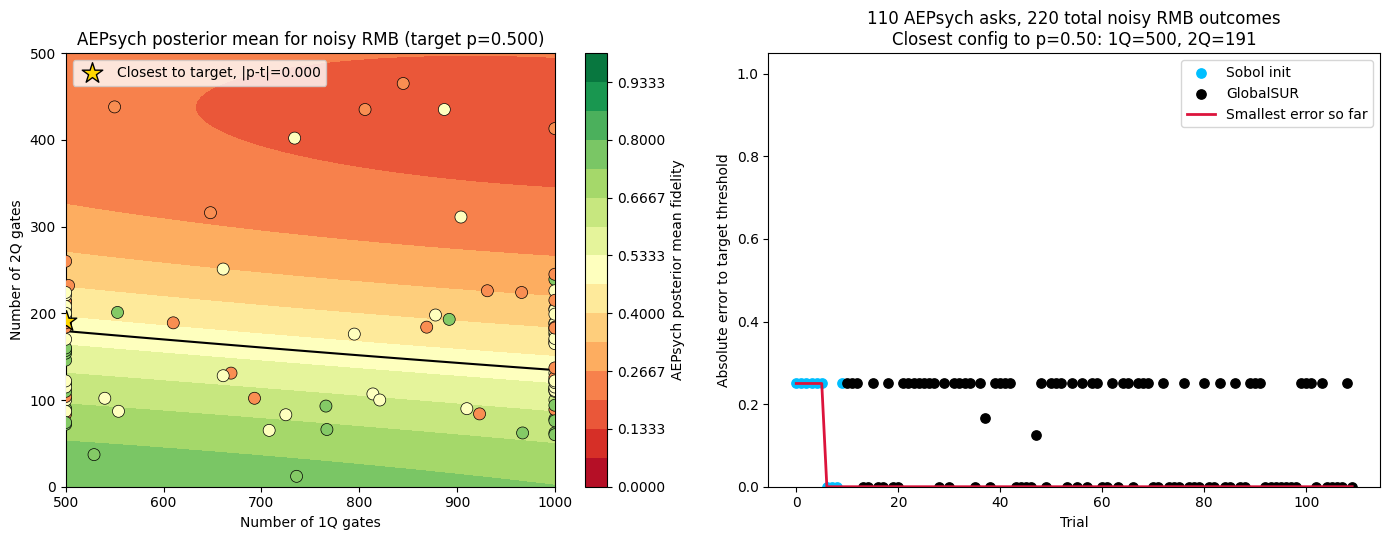

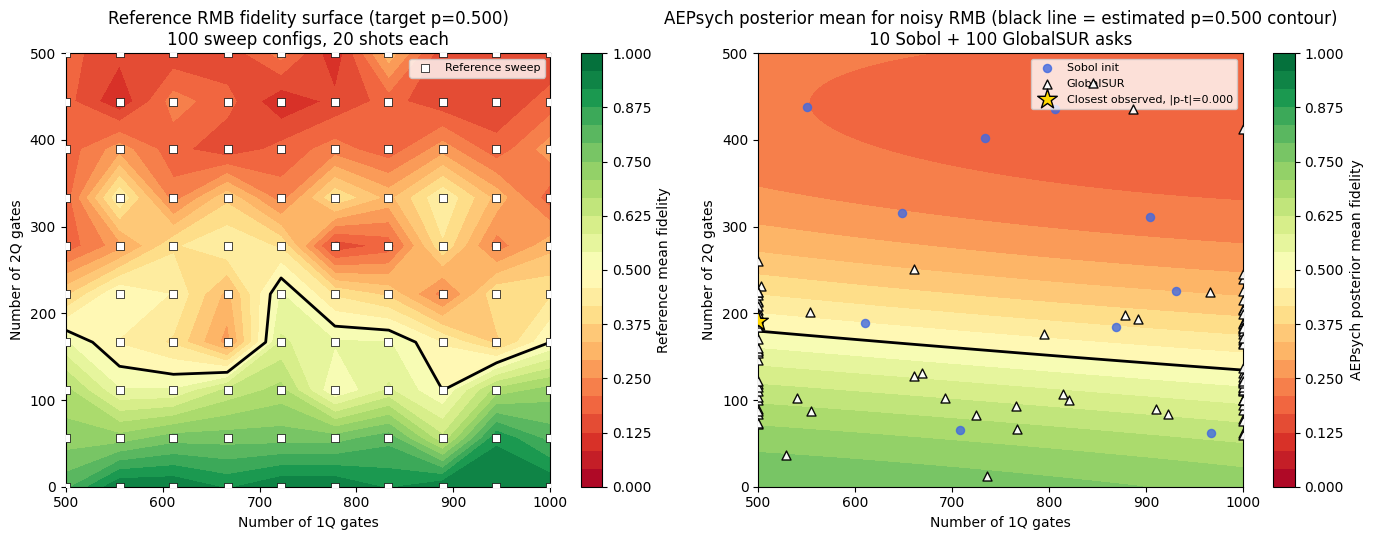

In [ ]:
from dataclasses import replace

RUN_SETTINGS = replace(
    SETTINGS,
    n_qubits=5,
    target_threshold=0.5,
    one_q_bounds=(0, 1000),
    two_q_bounds=(0, 300),
    initial_random_samples=20,
    optimization_steps=300,
    shots_per_step=2,
    inducing_size=50,
    acquisition_function="GlobalSUR",
    acquisition_restarts=8,
    acquisition_samples=20000,
    reference_one_q_points=30,
    reference_two_q_points=10,
    reference_shots_per_config=1000,
    plot_grid_size=300,
    rng_seed=0,
)

print("Using run settings:", RUN_SETTINGS)
reference_data = build_reference_data(RUN_SETTINGS)
strategy, rmb, results = run_optimization(RUN_SETTINGS)
plot_optimization_results(strategy, rmb, results, RUN_SETTINGS)
plot_comparison_results(strategy, rmb, results, reference_data, RUN_SETTINGS)